In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

In [21]:
folder_path = 'Boca3Jun26_200mW_200mW_2932cm_10x_G70_CARS_200x200_700x700_1us/'
txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]

In [22]:
# 1. Calcular a média mantendo a precisão dos valores negativos originais
matrix_sum = np.zeros((700, 700))
valid_file_count = 0

In [23]:
print("Calculando a matriz média...")
for file_name in txt_files:
    file_path = os.path.join(folder_path, file_name)
    try:
        df = pd.read_csv(file_path, sep=r'\s+', decimal=',', header=None)
        raw_array = df.to_numpy().flatten()
        if raw_array.size == 490000:
            matrix_sum += raw_array.reshape(700, 700)
            valid_file_count += 1
    except Exception as e:
        continue

avg_matrix = matrix_sum / valid_file_count
print(f"Média calculada! Valores originais -> Mínimo: {avg_matrix.min()}, Máximo: {avg_matrix.max()}")

# 2. SEGREDO: Normalização Min-Max para transformar valores negativos em estritamente positivos
min_val = avg_matrix.min()
max_val = avg_matrix.max()

# Transforma o intervalo de negativos para um intervalo seguro entre 0 e 1
avg_matrix_scaled = (avg_matrix - min_val) / (max_val - min_val)

# 3. Rodar o NMF na matriz positiva e escalada
print("Rodando a decomposição NMF...")
nmf_model = NMF(
    n_components=30, 
    init='random', 
    solver='cd', 
    max_iter=1000, 
    random_state=42
)

W = nmf_model.fit_transform(avg_matrix_scaled)
H = nmf_model.components_

Calculando a matriz média...
Média calculada! Valores originais -> Mínimo: -1.4432499999999997, Máximo: -0.4069642857142857
Rodando a decomposição NMF...


c:\conda\envs\apmaq\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 1000 reached. Increase it to improve convergence.
  warnings.warn(


Gerando os gráficos comparativos...


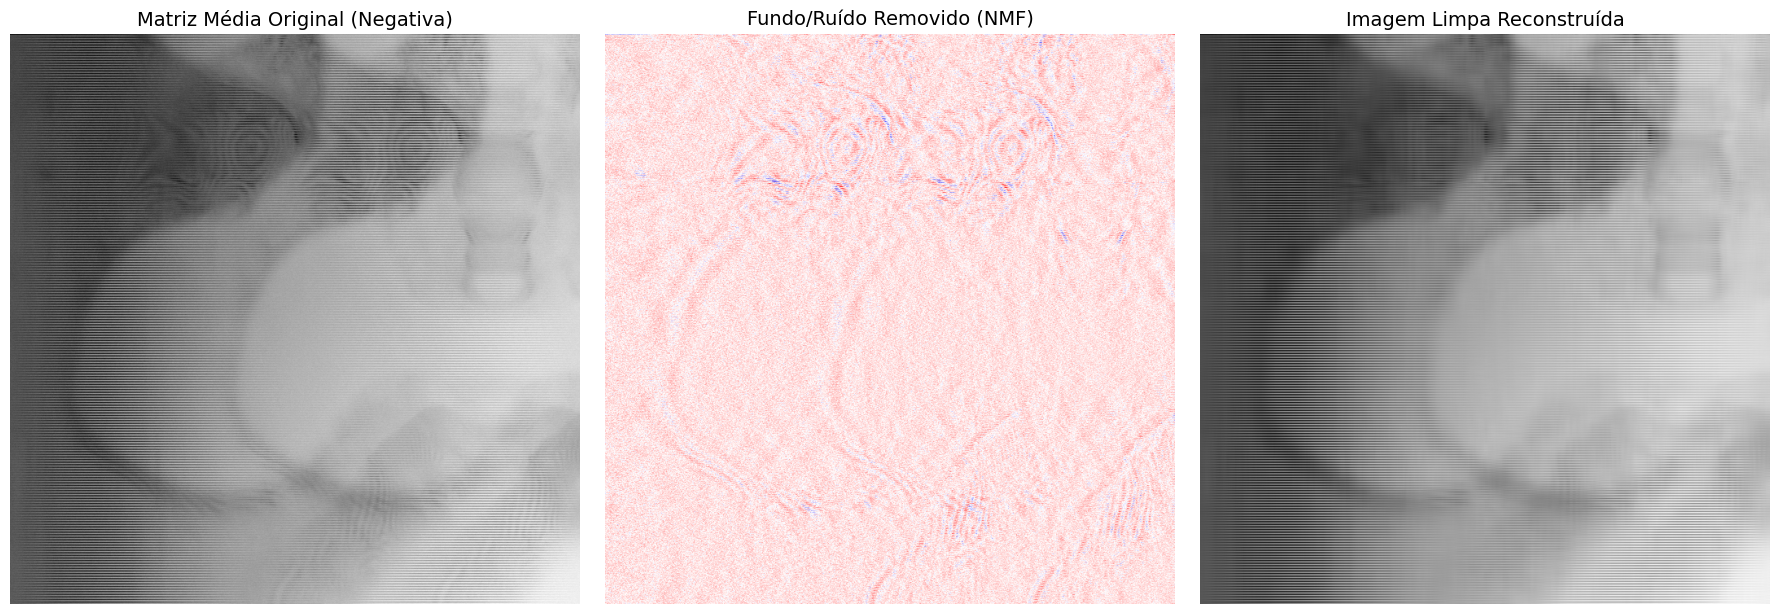

In [24]:


# 4. Reconstrução e retorno para a escala negativa original de intensidade
clean_nmf_scaled = np.dot(W, H)
# Desfazemos a normalização para o gráfico final mostrar a intensidade real do seu teste
clean_nmf_image = (clean_nmf_scaled * (max_val - min_val)) + min_val
nmf_noise_isolated = avg_matrix - clean_nmf_image

# 5. Plotar os resultados finais
print("Gerando os gráficos comparativos...")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(avg_matrix, cmap='gray')
axes[0].set_title('Matriz Média Original (Negativa)', fontsize=14)
axes[0].axis('off')

# O ruído isolado destacará o desvio de fase ou ruído eletrônico removido
axes[1].imshow(nmf_noise_isolated, cmap='bwr')
axes[1].set_title('Fundo/Ruído Removido (NMF)', fontsize=14)
axes[1].axis('off')

axes[2].imshow(clean_nmf_image, cmap='gray')
axes[2].set_title('Imagem Limpa Reconstruída', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('Resultados_CARS_NMF_Valores_Negativos.png', dpi=300)
plt.show()